# Credit Recovery Curve — Exploratory Analysis


In [41]:
import sys
from pathlib import Path

# Adiciona a pasta raiz do projeto ao caminho do Python
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src.data_cleaning import load_data
from src.recovery_metrics import (
    build_default_base,
    prepare_recovery_events,
    recovery_curve
)

customers, contracts, installments, recoveries = load_data()

base = build_default_base(
    contracts,
    installments
)

events = prepare_recovery_events(
    base,
    recoveries
)

recovery_curve(base, events)

,days_after_default,recovered_amount,recovery_rate
0,0,0.00,0.000000
1,30,10675340.45,0.156846
2,60,19260021.99,0.282976
3,90,26186886.24,0.384748
4,120,31635451.87,0.464800
5,180,35538154.36,0.522140
6,360,36553465.17,0.537057


In [42]:
base = build_default_base(contracts, installments)

print(f"Contratos em default: {len(base):,}")
print(f"Exposição no default: R$ {base['exposure_at_default'].sum():,.2f}")

Contratos em default: 5,978
Exposição no default: R$ 68,062,503.23


In [43]:
events = prepare_recovery_events(base, recoveries)

print(f"Eventos de recuperação: {len(events):,}")
print(f"Valor recuperado: R$ {events['recovery_amount'].sum():,.2f}")

Eventos de recuperação: 11,901
Valor recuperado: R$ 36,553,465.17


In [44]:
curve = recovery_curve(base, events)

curve

,days_after_default,recovered_amount,recovery_rate
0,0,0.00,0.000000
1,30,10675340.45,0.156846
2,60,19260021.99,0.282976
3,90,26186886.24,0.384748
4,120,31635451.87,0.464800
5,180,35538154.36,0.522140
6,360,36553465.17,0.537057


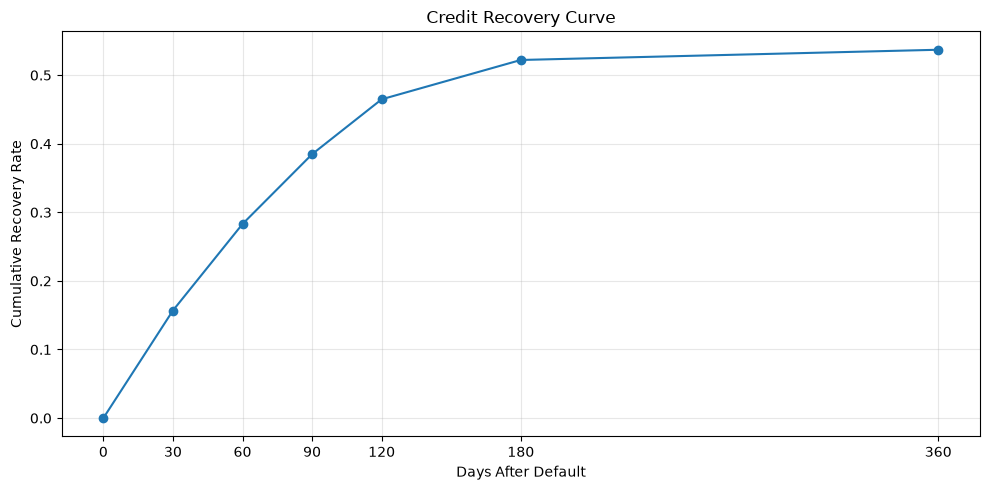

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    curve["days_after_default"],
    curve["recovery_rate"],
    marker="o"
)

plt.title("Credit Recovery Curve")
plt.xlabel("Days After Default")
plt.ylabel("Cumulative Recovery Rate")

plt.xticks(curve["days_after_default"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
recovery_180 = curve.loc[
    curve["days_after_default"] == 180,
    "recovery_rate"
].iloc[0]

recovery_360 = curve.loc[
    curve["days_after_default"] == 360,
    "recovery_rate"
].iloc[0]

total_exposure = base["exposure_at_default"].sum()
total_recovered = events["recovery_amount"].sum()

# Primeiro horizonte em que a recuperação atinge 50%
time_to_50 = curve.loc[
    curve["recovery_rate"] >= 0.50,
    "days_after_default"
].min()

print("=== CREDIT RECOVERY KPIs ===")
print(f"Exposure at Default : R$ {total_exposure:,.2f}")
print(f"Total Recovered     : R$ {total_recovered:,.2f}")
print(f"Recovery Rate @ 180d: {recovery_180:.2%}")
print(f"Recovery Rate @ 360d: {recovery_360:.2%}")
print(f"Time to 50% Recovery: {time_to_50} days")

=== CREDIT RECOVERY KPIs ===
Exposure at Default : R$ 68,062,503.23
Total Recovered     : R$ 36,553,465.17
Recovery Rate @ 180d: 52.21%
Recovery Rate @ 360d: 53.71%
Time to 50% Recovery: 180 days


## Interpretação de Negócio

A curva de recuperação apresenta uma visão de **quão rapidamente a carteira inadimplente gera recuperação financeira após a entrada em default**.

### Principais Insights

- A carteira atinge aproximadamente **50% de recuperação acumulada em até 180 dias** após o default.
- A recuperação cresce de forma mais acelerada nos **primeiros meses** e, posteriormente, começa a se estabilizar em horizontes mais longos.
- Aos **360 dias**, a taxa de recuperação acumulada atinge aproximadamente **53,7%**.
- A diferença entre as taxas de recuperação em **180 e 360 dias** indica que a maior parte da recuperação da carteira ocorre nas **etapas iniciais do ciclo de cobrança**.

### Aplicações no Negócio

Essa análise pode apoiar:

- **Monitoramento da performance de cobrança**;
- **Estimativa de recuperação esperada** da carteira;
- **Segmentação de portfólio**;
- **Análise de inadimplência e aging**;
- Comparação do **comportamento de recuperação entre produtos ou grupos de risco**;
- Suporte analítico à definição de **estratégias de crédito e cobrança**.